In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('dark_background')

df = pd.read_csv('Walmart_Store_sales.csv')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB
None
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0    6.0  18-02-2011    1572117.54           NaN        59.61       3.045   
1   13.0  25-03-2011    1807545.43           0.0        42.38       3.435   
2   17.0  27-07-2012           NaN           0.0          NaN         NaN   
3   11.0         NaN    1244390.03           0.0        84.57         NaN   
4    6.0  28-05-2010    

In [2]:
# Suppression des lignes où Weekly_Sales est vide
df = df.dropna(subset=['Weekly_Sales'])

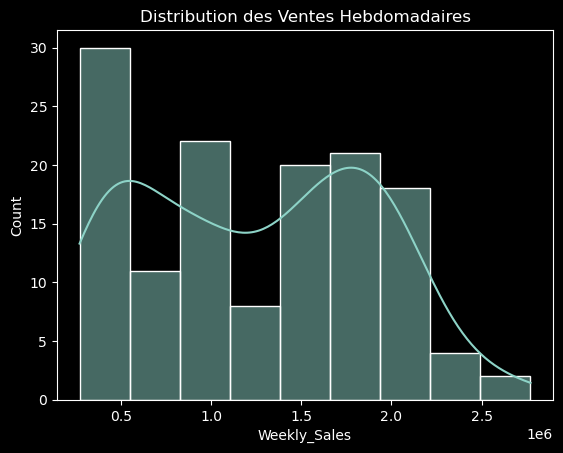

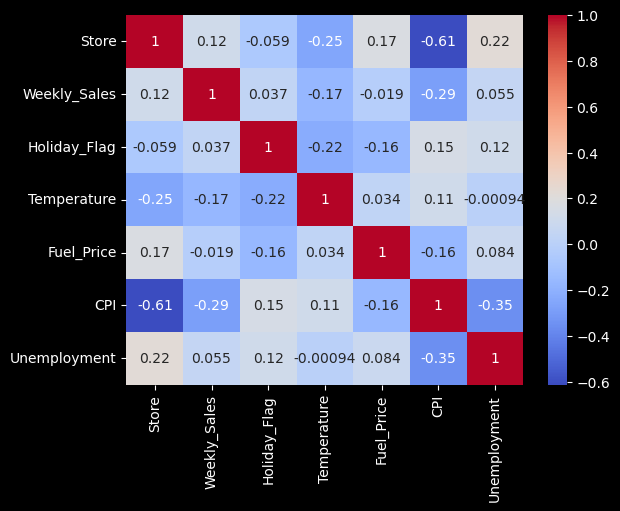

In [3]:
# Visualisation de la distribution des ventes
sns.histplot(df['Weekly_Sales'], kde=True)
plt.title('Distribution des Ventes Hebdomadaires')
plt.show()

# Heatmap de corrélation (uniquement sur les colonnes numériques)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

L'histogramme a 2 "bosses" (Bimodale), le pic de gauche (environ  400k$) représente probablement les petits magasins ou les semaines avec peu d'activité  et le pic de droite (environ 1.8m$)  représente probablement les gros magasins qui ont un volume de vente beaucoup plus élevé.

In [4]:
cols_to_clean = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for col in cols_to_clean:
    mean = df[col].mean()
    std = df[col].std()
    
# On ne garde que ce qui est à l'intérieur de l'intervalle
    df = df[(df[col] >= mean - 3*std) & (df[col] <= mean + 3*std)]

print(f"Nombre de lignes restantes après nettoyage : {len(df)}")

Nombre de lignes restantes après nettoyage : 90


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# On peut maintenant supprimer la colonne Date originale
df = df.drop('Date', axis=1)

C:\Users\Korvydae\AppData\Local\Temp\ipykernel_30088\327590086.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [6]:
target = "Weekly_Sales"

X = df.drop(target, axis=1)
Y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Liste des colonnes par type
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']
categorical_features = ['Store', 'Holiday_Flag']

# Création des sous-pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Remplace les NaN par la moyenne
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Remplace par le mode
    ('encoder', OneHotEncoder(drop='first'))
])

# Le reste du ColumnTransformer reste identique
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Application sur X_train et X_test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

R^2 sur le train set : 0.987
R^2 sur le test set : 0.935
                        Coefficient
cat__Store_4.0         2.210802e+06
cat__Store_13.0        2.073764e+06
cat__Store_10.0        1.805912e+06
cat__Store_19.0        1.334723e+06
cat__Store_14.0        1.019974e+06
cat__Store_18.0        9.941663e+05
cat__Store_17.0        8.626968e+05
num__CPI               7.206569e+05
cat__Store_15.0        5.956705e+05
cat__Store_20.0        5.926037e+05
cat__Store_2.0         2.713512e+05
cat__Store_11.0        2.193021e+05
cat__Store_6.0         9.988066e+04
num__Unemployment      3.220996e+04
num__Month             1.705793e+04
num__DayOfWeek         1.024455e-08
num__Year             -7.481771e+03
num__Temperature      -1.152028e+04
num__Day              -4.964542e+04
cat__Holiday_Flag_1.0 -5.362002e+04
num__Fuel_Price       -5.781748e+04
cat__Store_16.0       -5.762784e+05
cat__Store_7.0        -6.176032e+05
cat__Store_8.0        -6.568949e+05
cat__Store_9.0        -1.103226e+06
cat__St

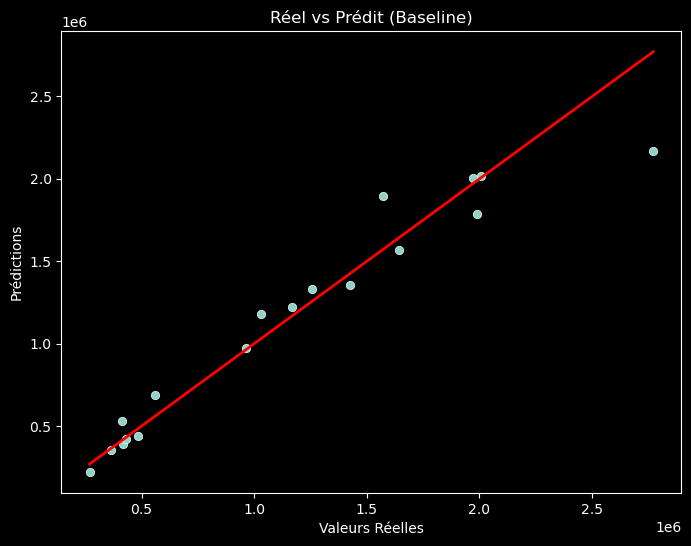

In [7]:
from sklearn.linear_model import LinearRegression

# Initialisation et entraînement
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

# Prédictions
y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)

# Scores R^2
print(f"R^2 sur le train set : {regressor.score(X_train, Y_train):.3f}")
print(f"R^2 sur le test set : {regressor.score(X_test, Y_test):.3f}")

# Récupérer les noms des colonnes après transformation
column_names = preprocessor.get_feature_names_out()

# Créer un DataFrame pour visualiser les coefficients
coeffs = pd.DataFrame(index=column_names, data=regressor.coef_, columns=['Coefficient'])
coeffs = coeffs.sort_values(by='Coefficient', ascending=False)

print(coeffs)

plt.figure(figsize=(8,6))
sns.scatterplot(x=Y_test, y=y_test_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', lw=2)
plt.xlabel('Valeurs Réelles')
plt.ylabel('Prédictions')
plt.title('Réel vs Prédit (Baseline)')
plt.show()


In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Définition de la grille de paramètres à tester
params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# Recherche de la meilleure configuration
ridge_grid = GridSearchCV(Ridge(), params, cv=5)
ridge_grid.fit(X_train, Y_train)

print(f"Meilleur alpha trouvé : {ridge_grid.best_params_}")
print(f"Meilleur score R^2 : {ridge_grid.best_score_:.3f}")

Meilleur alpha trouvé : {'alpha': 0.01}
Meilleur score R^2 : 0.953


**RAJOUTER LASSO**

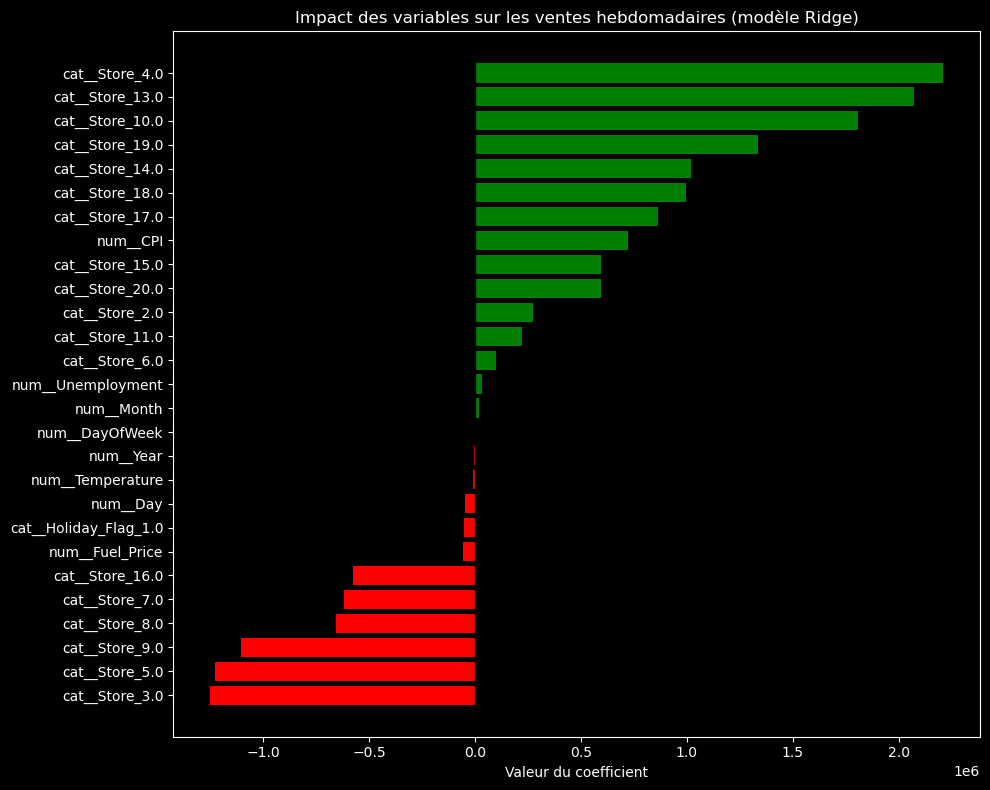

In [9]:
coeffs_sorted = coeffs.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in coeffs_sorted['Coefficient']]
plt.barh(coeffs_sorted.index, coeffs_sorted['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Impact des variables sur les ventes hebdomadaires (modèle Ridge)')
plt.xlabel('Valeur du coefficient')
plt.tight_layout()
plt.show()

Ce qu'on voit ici, c'est que l'emplacement du magasin (Store) est le facteur de loin le plus influent sur le volume des ventes, bien plus que les indicateurs économiques comme le prix de l'essence ou la météo.

**Analyse des coefficients :**

L'effet "Emplacement" (Les Stores) : Les coefs des magasins 4, 13 et 10 sont elévés. Cela signifie que ces magasins génèrent plus de chiffre d'affaires.
À l'inverse, les magasins 3, 5 et 9 vendent moins (coefficients négatifs). Ces magasins ont peut-être une zone de chalandise plus petite ou moins de trafic.

L'impact Économique (num__...) : 
- CPI (Indice des prix à la consommation) : Coefficient positif significatif . Probablement qu'une hausse des prix (inflation) est corrélée à une hausse des ventes en valeur (les gens paient plus cher les mêmes produits).
- Unemployment : L'impact est positif mais faible.
- Fuel_Price & Temperature ont un impact négatif. Quand le prix de l'essence monte, les ventes ont tendance à baisser légèrement (les clients limitent peut-être leurs déplacements ou ont moins de budget pour leurs achats).

L'impact des vacances (Holiday_Flag) est légèrement négatif. Peut-être que les ventes chutent juste après les grands pics de consommation ou si certains magasins spécifiques ferment pendant les jours fériés.